In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# MaxAbsScaler = X/[Xmax] in which your max always 1 when you scaled the values

In [4]:
df = pd.read_csv("wine_data.csv",header=None,usecols=[0,1,2,3])

df.columns = ["Class Label","Alcohal","Malic Acid","Ash"]

df

,Class Label,Alcohal,Malic Acid,Ash
0,1,14.23,1.71,2.43
1,1,13.20,1.78,2.14
2,1,13.16,2.36,2.67
3,1,14.37,1.95,2.50
4,1,13.24,2.59,2.87
...,...,...,...,...
173,3,13.71,5.65,2.45
174,3,13.40,3.91,2.48
175,3,13.27,4.28,2.26
176,3,13.17,2.59,2.37


<Axes: xlabel='Alcohal', ylabel='Density'>

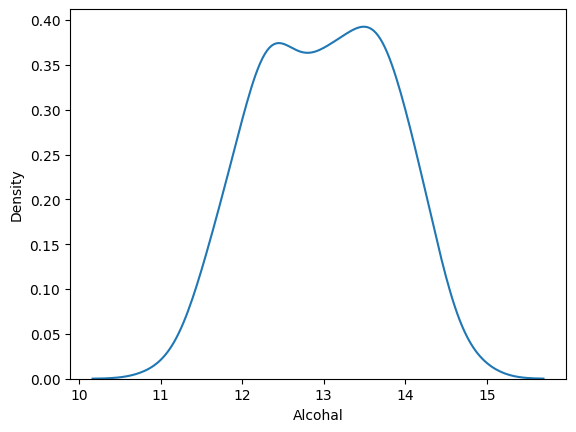

In [11]:
sns.kdeplot(df["Alcohal"])

<Axes: xlabel='Bear', ylabel='Density'>

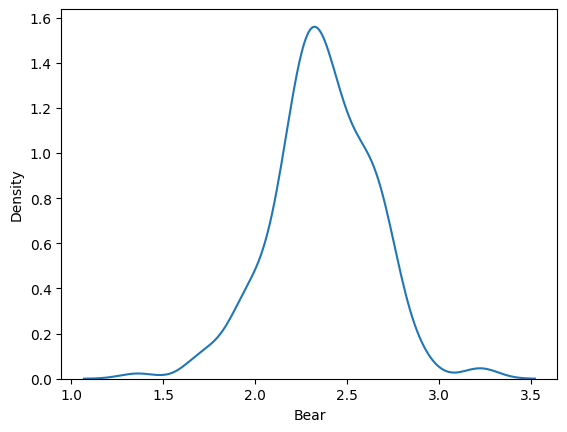

In [12]:
sns.kdeplot(df["Bear"])

<Axes: xlabel='Alcohal', ylabel='Ash'>

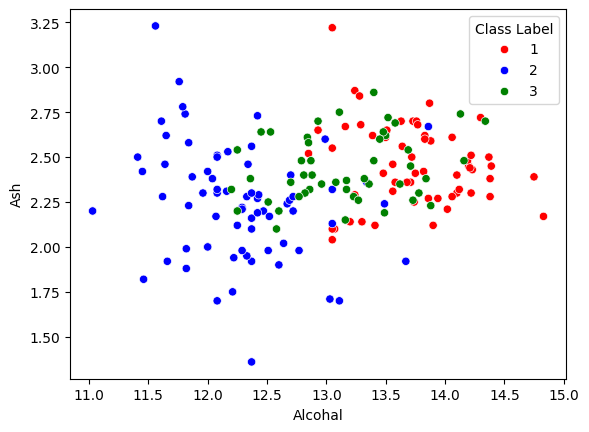

In [17]:
color_dict={1:"red",2:"blue",3:"green"}
sns.scatterplot(x=df["Alcohal"],y=df["Ash"],hue=df["Class Label"],palette=color_dict)

In [5]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(df.drop("Class Label",axis=1),
                                                 df["Class Label"],
                                                 test_size=0.3,
                                                 random_state=0
)

In [11]:
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((124, 3), (54, 3), (124,), (54,))

In [13]:
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()

scaler.fit(X_train)

X_train_Scaled = scaler.transform(X_train)
X_test_Scaled = scaler.transform(X_test)

In [14]:
X_train_Scaled

array([[0.92949153, 0.32920354, 0.73291925],
       [0.82847458, 0.22831858, 0.60248447],
       [0.89966102, 0.75752212, 0.70186335],
       [0.89220339, 0.63185841, 0.66770186],
       [0.93966102, 0.26725664, 0.82919255],
       [0.87118644, 0.57876106, 0.80124224],
       [0.93830508, 0.72920354, 0.73913043],
       [0.90169492, 0.30442478, 0.66459627],
       [0.88474576, 0.68318584, 0.72049689],
       [0.84813559, 0.21946903, 0.69875776],
       [0.83322034, 0.24955752, 0.61490683],
       [0.86576271, 0.60707965, 0.61490683],
       [0.87864407, 0.61061947, 0.72981366],
       [0.92677966, 0.22123894, 0.59627329],
       [0.89220339, 0.41769912, 0.82919255],
       [0.83864407, 0.16637168, 0.42236025],
       [0.84542373, 0.26902655, 0.68322981],
       [0.80067797, 0.37522124, 0.85093168],
       [0.89762712, 0.70442478, 0.71118012],
       [0.9559322 , 0.38230088, 0.71428571],
       [0.78711864, 0.23893805, 0.83850932],
       [0.88067797, 0.29557522, 0.80745342],
       [0.

In [16]:
X_train_Scaled = pd.DataFrame(X_train_Scaled,columns=X_train.columns)
X_test_Scaled = pd.DataFrame(X_test_Scaled,columns=X_test.columns)

In [18]:
X_train_Scaled,X_test_Scaled

(      Alcohal  Malic Acid       Ash
 0    0.929492    0.329204  0.732919
 1    0.828475    0.228319  0.602484
 2    0.899661    0.757522  0.701863
 3    0.892203    0.631858  0.667702
 4    0.939661    0.267257  0.829193
 ..        ...         ...       ...
 119  0.801356    0.304425  0.583851
 120  0.838644    0.207080  0.596273
 121  0.842034    0.284956  0.680124
 122  0.942373    0.297345  0.658385
 123  0.960000    0.444248  0.770186
 
 [124 rows x 3 columns],
      Alcohal  Malic Acid       Ash
 0   0.931525    0.295575  0.698758
 1   0.867119    0.472566  0.770186
 2   0.838644    0.200000  0.670807
 3   0.919322    0.306195  0.763975
 4   0.884746    1.026549  0.661491
 5   0.783729    0.362832  1.003106
 6   0.953220    0.380531  0.810559
 7   0.837966    0.677876  0.739130
 8   0.830508    0.306195  0.658385
 9   0.818983    0.323894  0.720497
 10  0.905763    0.453097  0.729814
 11  0.941017    0.892035  0.692547
 12  0.962712    0.311504  0.760870
 13  0.838644    0.189381

In [19]:
np.round(X_train.describe(),1)

,Alcohal,Malic Acid,Ash
count,124.0,124.0,124.0
mean,13.0,2.4,2.4
std,0.8,1.1,0.3
min,11.0,0.9,1.4
25%,12.4,1.6,2.2
50%,13.0,1.9,2.4
75%,13.6,3.2,2.6
max,14.8,5.6,3.2


In [21]:
np.round(X_train_Scaled.describe(),1)

,Alcohal,Malic Acid,Ash
count,124.0,124.0,124.0
mean,0.9,0.4,0.7
std,0.1,0.2,0.1
min,0.7,0.2,0.4
25%,0.8,0.3,0.7
50%,0.9,0.3,0.7
75%,0.9,0.6,0.8
max,1.0,1.0,1.0


Text(0.5, 1.0, 'After Scaling')

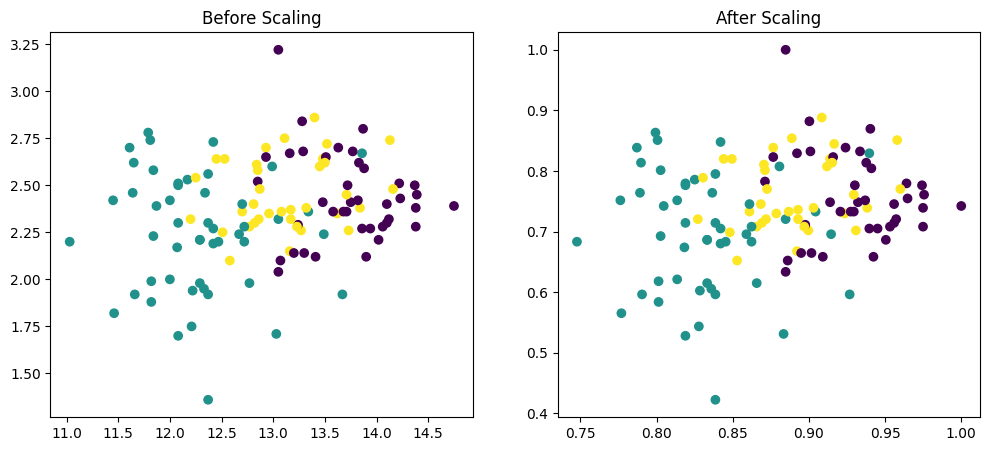

In [22]:
ig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(X_train["Alcohal"],X_train["Ash"],c=Y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_Scaled["Alcohal"],X_train_Scaled["Ash"],c=Y_train)
ax2.set_title("After Scaling")

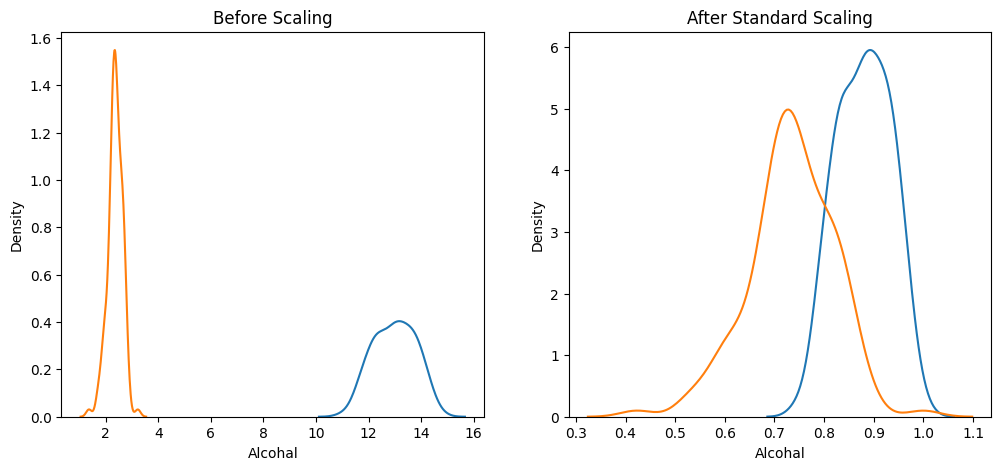

In [23]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohal'], ax=ax1)
sns.kdeplot(X_train['Ash'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling using MaxAbsScaler')
sns.kdeplot(X_train_Scaled['Alcohal'], ax=ax2)
sns.kdeplot(X_train_Scaled['Ash'], ax=ax2)
plt.show()

<Axes: title={'center': 'Ash Distribution after scaling'}, xlabel='Ash', ylabel='Density'>

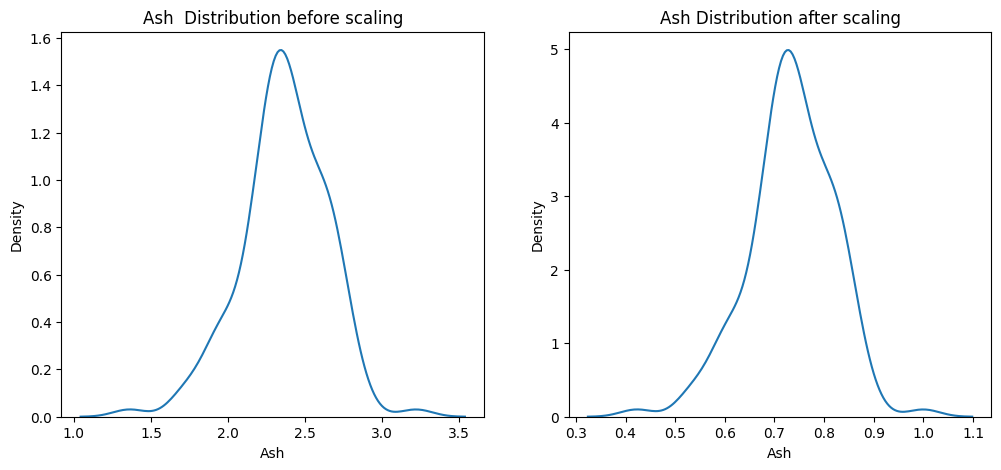

In [29]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title("Ash  Distribution before scaling")
sns.kdeplot(X_train["Ash"],ax=ax1)

ax2.set_title("Ash Distribution after scaling")
sns.kdeplot(X_train_Scaled["Ash"],ax=ax2)